# Example: Single Index Model Inputs and Minimum-Variance Portfolios
In this example, we build the two inputs of the minimum-variance allocation problem, the expected growth-rate vector and the growth-rate covariance matrix, two ways for the same set of firms: directly from the 2014 to 2024 growth-rate data, as in L5b, and from the single index model (SIM) parameters that the L6a example estimated from the same data. We compare the two covariance matrices entry by entry, trace the long-only efficient frontier from each, compare the weights the two frontiers select, and then check how the portfolios did on a year of prices neither input set saw.

> __Learning Objectives:__
>
> By the end of this example, you should be able to:
> * __Assemble the SIM inputs for a portfolio:__ Read the estimated intercepts, betas, and residual variances from the SIM archive, combine them with the training-period market mean and variance into $\hat{\mathbf{g}}_{\text{SIM}}$ and $\hat{\mathbf{\Sigma}}_{g,\text{SIM}}$, and verify that the SIM mean vector reproduces the sample means exactly.
> * __Locate the SIM covariance error:__ Show that the SIM covariance is the sample covariance with every off-diagonal residual covariance set to zero, and read which pairs of firms that assumption misdescribes.
> * __Compare the frontiers and the portfolios:__ Trace the long-only efficient frontier from each input set, evaluate the SIM-selected weights under the data covariance, compare the weights at a target growth rate, and score the portfolios out of sample on 2025 data.

Let's get started!
___

## Setup, Data, and Prerequisites
First, we set up the computational environment by including the `Include.jl` file and loading any needed resources.

> __Include:__ The [`include(...)` command](https://docs.julialang.org/en/v1/base/base/#include) evaluates the contents of the input source file, `Include.jl`, in the notebook's global scope. The `Include.jl` file sets paths, loads required external packages, etc. For additional information on functions and types used in this material, see the [Julia programming language documentation](https://docs.julialang.org/en/v1/). 

Let's set up our code environment:

In [1]:
include(joinpath(@__DIR__, "Include.jl")); # include the Include.jl file

  Activating project at `~/Desktop/julia_work/CHEME-5660-CourseRepository-Fall-2026`


The `Include.jl` file loads the course package [VLQuantitativeFinancePackage.jl](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/), together with [DataFrames.jl](https://dataframes.juliadata.org/stable/), [Statistics](https://docs.julialang.org/en/v1/stdlib/Statistics/), [LinearAlgebra](https://docs.julialang.org/en/v1/stdlib/LinearAlgebra/), [JLD2.jl](https://juliaio.github.io/JLD2.jl/stable/), [Plots.jl](https://docs.juliaplots.org/stable/), and [PrettyTables.jl](https://ronisbr.github.io/PrettyTables.jl/stable/). For additional information on functions and types used in this material, see the [Julia programming language documentation](https://docs.julialang.org/en/v1/) and the [CHEME 5660 Quantitative Finance Package documentation](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/).

### Data
We gathered daily open-high-low-close (OHLC) data for each firm in the [S&P 500](https://en.wikipedia.org/wiki/S%26P_500) from `01-03-2014` until `12-31-2024`, along with data for several exchange-traded funds and volatility products during that time period. This is the __training__ data: the SIM parameters in the archive were estimated from it, and every data-driven input below is estimated from it. We also load the __testing__ data, calendar year 2025 (`01-02-2025` until `12-31-2025`), which we use only in the last task to see how the portfolios did on prices neither input set saw.

Let's load the training data by calling [the `MyTrainingMarketDataSet()` function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/data/#VLQuantitativeFinancePackage.MyTrainingMarketDataSet), keep only the firms with the maximum number of trading days (firms with fewer records were acquired or delisted during the period), and store the cleaned data in the `dataset::Dict{String,DataFrame}` variable:

In [2]:
dataset = let

    # initialize -
    original_dataset = MyTrainingMarketDataSet() |> x-> x["dataset"]; # training data, 2014 to 2024
    maximum_number_trading_days = original_dataset["AAPL"] |> nrow; # AAPL has the maximum number of trading days
    dataset = Dict{String, DataFrame}();

    # keep only the firms with the maximum number of trading days -
    for (ticker, data) ∈ original_dataset
        if (nrow(data) == maximum_number_trading_days)
            dataset[ticker] = data;
        end
    end
    dataset; # return
end;

Next, we do the same for the testing data by calling [the `MyTestingMarketDataSet()` function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/data/#VLQuantitativeFinancePackage.MyTestingMarketDataSet), and store the cleaned 2025 data in the `dataset_2025::Dict{String,DataFrame}` variable:

In [3]:
dataset_2025 = let

    # initialize -
    original_dataset = MyTestingMarketDataSet() |> x-> x["dataset"]; # testing data, calendar year 2025
    maximum_number_trading_days = original_dataset["AAPL"] |> nrow;
    dataset = Dict{String, DataFrame}();

    # keep only the firms with the maximum number of trading days -
    for (ticker, data) ∈ original_dataset
        if (nrow(data) == maximum_number_trading_days)
            dataset[ticker] = data;
        end
    end
    dataset; # return
end;

Finally, we load the single index model archive that the L6a estimation example saved, `SIMs-SP500-01-03-14-to-12-31-24.jld2`, [using the `JLD2.load(...)` function](https://juliaio.github.io/JLD2.jl/stable/). The archive holds, for every security fitted against SPY on the training data, the estimated intercept $\hat{\alpha}_{i}$ and beta $\hat{\beta}_{i}$ (fields `alpha`, `beta`), the residual growth-rate variance $s^{2}_{g,\varepsilon,i}$ (field `training_variance`, units: inverse years squared, no time-step factor), and their standard errors and fit statistics; and, once for the whole archive, the training-period sample mean $g^{\prime}_{M}$ and sample variance $s^{2}_{g,M}$ of the market growth rate (keys `market_mean` and `market_variance`). We check that the archive uses the growth-rate variance convention of the lecture and store the per-ticker parameters in the `sim_parameters::Dict{String,NamedTuple}` variable and the two market moments in the `g_market_mean::Float64` and `σ²_market::Float64` variables:

In [4]:
sim_parameters, g_market_mean, σ²_market = let
    archive = JLD2.load(joinpath(_PATH_TO_DATA, "SIMs-SP500-01-03-14-to-12-31-24.jld2"));
    @assert archive["variance_convention"] == "growth_rate" # residual variances are Var(ε) in (1/years)², as in the lecture
    println("SIM archive: $(length(archive["data"])) securities fitted against $(archive["market_ticker"]) on $(archive["date_range"][1][1:10]) to $(archive["date_range"][2][1:10])")
    (archive["data"], archive["market_mean"], archive["market_variance"]); # return
end;

SIM archive: 424 securities fitted against SPY on 2014-01-03 to 2024-12-31


### Constants
Finally, let's specify some constants that we will use in our analysis. Check out the comments for details on the constants, their permissible values, units, etc.

In [5]:
Δt = (1.0/252.0); # time step (1 trading day, in years)
W₀ = 1000.0; # initial wealth (units: USD)
number_of_points = 101; # number of target growth rates in each frontier sweep
g_target = 0.20; # target growth rate at which we compare the two allocations (units: 1/years)

___

## Task 1: Data-Driven Inputs for a Chosen Set of Firms
We start where L5b left off. For the same thirteen firms as the L5b example (technology, semiconductors, banks, automakers, and a health-care firm; change the list if you like, every cell below adapts, and the list is chosen without looking at 2025 so the last task stays honest), specify the ticker symbols in the `my_list_of_tickers::Array{String,1}` array:

In [6]:
my_list_of_tickers = ["AAPL", "MSFT", "INTC", "MU", "AMD", "NVDA", "GS", "BAC", "WFC", "C", "F", "GM", "JNJ"]; # |𝒫| = 13 firms, as in L5b

We build the growth-rate data matrix $\mathbf{G}$ (rows are the $N$ trading days, columns are the firms in the order of `my_list_of_tickers`) [using the `log_growth_matrix(...)` function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/equity/#VLQuantitativeFinancePackage.log_growth_matrix), and from it the sample-mean growth-rate vector $\hat{\mathbf{g}}$ (the estimate of $\bar{\mathbf{g}}$, units: inverse years) and the growth-rate covariance matrix $\hat{\mathbf{\Sigma}}_{g}$ (units: inverse years squared), exactly as in L5b. We also pull out the market growth-rate series $g_{M,t}$ (the SPY column of the full training data), because the next task checks the archive's market moments against it. We check that the firms share the same trading dates in both datasets and store the results in the `ĝ::Array{Float64,1}`, `Σ̂_g::Array{Float64,2}`, and `g_market::Array{Float64,1}` variables:

In [7]:
ĝ, Σ̂_g, g_market = let

    # check: the chosen firms share the same trading dates (rows are aligned by position) -
    for ticker ∈ vcat(my_list_of_tickers, "SPY")
        @assert dataset[ticker].timestamp == dataset["AAPL"].timestamp
        @assert dataset_2025[ticker].timestamp == dataset_2025["AAPL"].timestamp
    end

    # build the growth-rate data matrix (N trading days × |𝒫| firms) and the market series -
    G = log_growth_matrix(dataset, my_list_of_tickers, Δt = Δt); # growth rates g (units: 1/years)
    g_market = log_growth_matrix(dataset, ["SPY"], Δt = Δt) |> vec; # market growth rates g_M,t (units: 1/years)

    # estimate the data-driven inputs -
    ĝ = mean(G, dims=1) |> vec; # sample-mean growth rate for each firm (units: 1/years)
    Σ̂_g = cov(G, dims=1); # growth-rate covariance Cov(g) (units: 1/years²)
    @assert isposdef(Σ̂_g)

    (ĝ, Σ̂_g, g_market); # return
end;
println("N = $(length(g_market)) training days; |𝒫| = $(length(my_list_of_tickers)) firms")

N = 2766 training days; |𝒫| = 13 firms


___

## Task 2: SIM Inputs from the Archive
The lecture assembles the SIM inputs from one intercept, one beta, and one residual variance per firm plus the two market moments:
$$
\hat{\mathbf{g}}_{\text{SIM}} = \hat{\boldsymbol{\alpha}} + \hat{\boldsymbol{\beta}}\,g^{\prime}_{M},\qquad
\hat{\mathbf{\Sigma}}_{g,\text{SIM}} = s^{2}_{g,M}\,\hat{\boldsymbol{\beta}}\hat{\boldsymbol{\beta}}^{\top} + \hat{\mathbf{D}}_{g},\qquad
\hat{\mathbf{D}}_{g} = \text{diag}\left(s^{2}_{g,\varepsilon,1},\dots,s^{2}_{g,\varepsilon,|\mathcal{P}|}\right)
$$
Both market moments must come from the __training__ period, the same window the intercepts and betas were fitted on: the archive stores them for exactly that reason. First we confirm that the archive's `market_mean` and `market_variance` are the sample mean and variance of the SPY growth-rate series we just built, then we look up the thirteen firms and assemble the inputs. We store them in the `ĝ_sim::Array{Float64,1}` and `Σ̂_g_sim::Array{Float64,2}` variables, and keep the intercepts, betas, and residual variances in the `α̂::Array{Float64,1}`, `β̂::Array{Float64,1}`, and `s²_ε::Array{Float64,1}` variables:

In [8]:
ĝ_sim, Σ̂_g_sim, α̂, β̂, s²_ε = let

    # check: the archive's market moments are the training-period sample moments of SPY -
    @assert isapprox(g_market_mean, mean(g_market), rtol = 1e-10)
    @assert isapprox(σ²_market, var(g_market), rtol = 1e-10)

    # look up the SIM parameters for our firms -
    α̂ = [sim_parameters[ticker].alpha for ticker ∈ my_list_of_tickers]; # intercepts (units: 1/years)
    β̂ = [sim_parameters[ticker].beta for ticker ∈ my_list_of_tickers]; # betas (dimensionless)
    s²_ε = [sim_parameters[ticker].training_variance for ticker ∈ my_list_of_tickers]; # residual variances (units: 1/years²)

    # assemble the SIM inputs -
    ĝ_sim = α̂ .+ β̂ .* g_market_mean; # SIM mean vector (units: 1/years)
    Σ̂_g_sim = σ²_market .* (β̂ * β̂') .+ Diagonal(s²_ε); # rank one plus diagonal (units: 1/years²)
    @assert isposdef(Σ̂_g_sim) # every residual variance is positive, so the SIM covariance is positive definite

    (ĝ_sim, Matrix(Σ̂_g_sim), α̂, β̂, s²_ε); # return
end;

### The SIM mean vector is the sample-mean vector
A least-squares line fitted with an intercept passes through the point of sample means, so $\hat{\alpha}_{i}+\hat{\beta}_{i}\,g^{\prime}_{M}=g^{\prime}_{i}$ for every firm: when the SIM is fitted on the same trading days used for the sample means, the SIM mean vector __is__ the sample-mean vector. Let's verify it. The two approaches therefore agree on the reward input; everything that differs between them below comes from the covariance:

In [9]:
let
    println("max |ĝ_sim - ĝ| = $(maximum(abs.(ĝ_sim .- ĝ))) 1/yr (machine precision: the SIM mean vector reproduces the sample means)")
    @assert isapprox(ĝ_sim, ĝ, rtol = 1e-10, atol = 1e-10) # exact in real arithmetic; the tolerance is for floating point
end

max |ĝ_sim - ĝ| = 1.1102230246251565e-15 1/yr (machine precision: the SIM mean vector reproduces the sample means)


### The SIM covariance is the sample covariance with the residual covariances removed
Write each firm's fitted residual series as $\mathbf{r}_{i}=\mathbf{y}_{i}-\hat{\alpha}_{i}\mathbf{1}-\hat{\beta}_{i}\,\mathbf{g}_{M}$. Least squares makes every residual series orthogonal to the column of ones and to the market column, so the sample covariance of two firms decomposes exactly as $\hat{\Sigma}_{g,ij}=\hat{\beta}_{i}\hat{\beta}_{j}\,s^{2}_{g,M}+\widehat{\text{Cov}}(\mathbf{r}_{i},\mathbf{r}_{j})$: the SIM off-diagonal entry plus the sample covariance of the two residual series. The SIM sets that residual covariance to zero, so off the diagonal the difference $\hat{\mathbf{\Sigma}}_{g}-\hat{\mathbf{\Sigma}}_{g,\text{SIM}}$ is __exactly__ the residual covariance $\widehat{\text{Cov}}(\mathbf{r}_{i},\mathbf{r}_{j})$ (the residual correlations L6a measured, scaled by the two residual standard deviations); on the diagonal the sample variance divides the squared residuals by $N-1$ while the regression estimate $s^{2}_{g,\varepsilon,i}$ divides by $N-2$, so the SIM diagonal is larger by the factor $(N-1)/(N-2)$ on the residual term, a difference of a few parts in ten thousand here. Let's rebuild the residual series for our firms and check both statements, storing the residual covariance matrix in the `Ω̂_ε::Array{Float64,2}` variable:

In [10]:
Ω̂_ε = let
    N = length(g_market);
    G = log_growth_matrix(dataset, my_list_of_tickers, Δt = Δt);
    R = G .- (ones(N)*α̂' .+ g_market*β̂'); # fitted residual series, one column per firm
    Ω̂_ε = cov(R, dims=1); # residual covariance matrix (units: 1/years²)

    # check: off the diagonal, data covariance = SIM covariance + residual covariance, exactly -
    difference = Σ̂_g .- Σ̂_g_sim;
    off_diagonal_error = maximum(abs.((difference .- Ω̂_ε)[i,j]) for i ∈ 1:length(my_list_of_tickers), j ∈ 1:length(my_list_of_tickers) if i != j);
    println("max off-diagonal |Σ̂_g - Σ̂_g_sim - Ω̂_ε| = $(off_diagonal_error) 1/yr² (exact decomposition)")

    # check: on the diagonal, the two differ only by the N-1 versus N-2 factor on the residual term -
    println("diagonal ratio Σ̂_g_sim / Σ̂_g between $(round(minimum(diag(Σ̂_g_sim) ./ diag(Σ̂_g)), digits=5)) and $(round(maximum(diag(Σ̂_g_sim) ./ diag(Σ̂_g)), digits=5)); (N-1)/(N-2) = $(round((N-1)/(N-2), digits=5))")
    Ω̂_ε; # return
end;

max off-diagonal |Σ̂_g - Σ̂_g_sim - Ω̂_ε| = 1.3322676295501878e-14 1/yr² (exact decomposition)
diagonal ratio Σ̂_g_sim / Σ̂_g between 1.00017 and 1.00028; (N-1)/(N-2) = 1.00036


Which pairs does the SIM misdescribe? Let's look at the two correlation matrices side by side, on the same diverging color scale (blue positive, red negative, white zero) [using the `heatmap(...)` function](https://docs.juliaplots.org/stable/api/#Plots.heatmap-Tuple): the data-driven correlation on the left, the SIM-implied correlation on the right. `Unhide` the code block below to see how we made the plot:

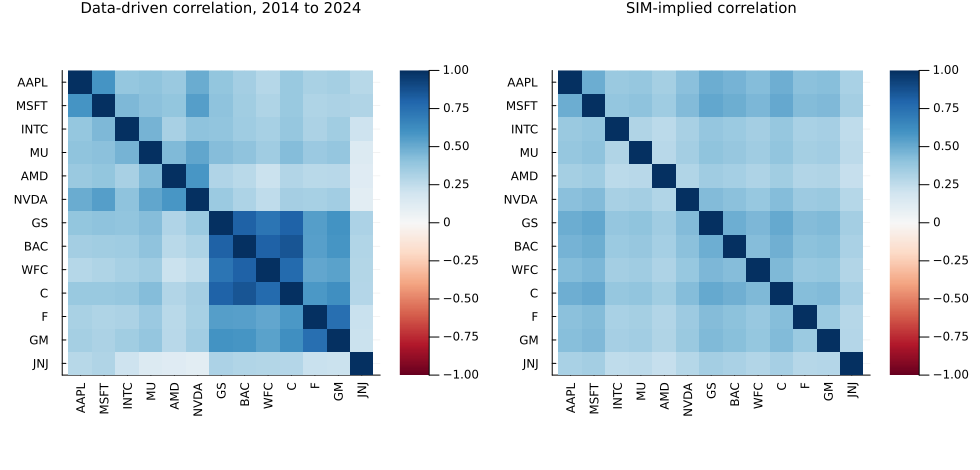

In [11]:
let
    number_of_assets = length(my_list_of_tickers);
    ρ̂ = Σ̂_g ./ (sqrt.(diag(Σ̂_g)) * sqrt.(diag(Σ̂_g))');
    ρ̂_sim = Σ̂_g_sim ./ (sqrt.(diag(Σ̂_g_sim)) * sqrt.(diag(Σ̂_g_sim))');
    p1 = heatmap(ρ̂, xticks = (1:number_of_assets, my_list_of_tickers), yticks = (1:number_of_assets, my_list_of_tickers), xrotation = 90,
        color = :RdBu, clims = (-1, 1), colorbar_ticks = (-1:0.5:1), aspect_ratio = :equal, yflip = true,
        title = "Data-driven correlation, 2014 to 2024", titlefontsize = 10);
    p2 = heatmap(ρ̂_sim, xticks = (1:number_of_assets, my_list_of_tickers), yticks = (1:number_of_assets, my_list_of_tickers), xrotation = 90,
        color = :RdBu, clims = (-1, 1), colorbar_ticks = (-1:0.5:1), aspect_ratio = :equal, yflip = true,
        title = "SIM-implied correlation", titlefontsize = 10);
    plot(p1, p2, layout = (1, 2), size = (980, 470), left_margin = 2Plots.mm, bottom_margin = 4Plots.mm)
end

The SIM flattens the correlation structure to a single market-driven pattern: every off-diagonal entry is $\hat{\beta}_{i}\hat{\beta}_{j}s^{2}_{g,M}$ divided by the two total growth-rate standard deviations, so the pattern is set by the betas and the total standard deviations (a high-beta firm with a large residual variance is not strongly correlated with anything) and there are no blocks. The data have blocks: the banks with each other, the automakers with each other, and the semiconductor firms with each other are more correlated than their betas say, and the technology firms with the banks are less. Let's put numbers on that with the residual correlation matrix and list the pairs with the largest positive and the largest negative residual correlations:

In [12]:
let
    number_of_assets = length(my_list_of_tickers);
    ρ̂_ε = Ω̂_ε ./ (sqrt.(diag(Ω̂_ε)) * sqrt.(diag(Ω̂_ε))'); # residual correlation matrix
    pairs = [(my_list_of_tickers[i], my_list_of_tickers[j], ρ̂_ε[i,j]) for i ∈ 1:number_of_assets for j ∈ (i+1):number_of_assets];
    sort!(pairs, by = x -> x[3]);
    df = DataFrame(pair = String[], residual_corr = Float64[], data_corr = Float64[], SIM_corr = Float64[]);
    ρ̂ = Σ̂_g ./ (sqrt.(diag(Σ̂_g)) * sqrt.(diag(Σ̂_g))');
    ρ̂_sim = Σ̂_g_sim ./ (sqrt.(diag(Σ̂_g_sim)) * sqrt.(diag(Σ̂_g_sim))');
    for (a, b, r) ∈ vcat(pairs[end:-1:end-4], pairs[1:5]) # five most positive, five most negative
        i = findfirst(==(a), my_list_of_tickers); j = findfirst(==(b), my_list_of_tickers);
        push!(df, (pair = "$(a)-$(b)", residual_corr = round(r, digits=3), data_corr = round(ρ̂[i,j], digits=3), SIM_corr = round(ρ̂_sim[i,j], digits=3)));
    end
    pretty_table(df, backend = :text, table_format = TextTableFormat(borders = text_table_borders__compact))
    println("median |residual correlation| over the $(length(pairs)) pairs: $(round(median(abs.(getindex.(pairs, 3))), digits=3))")
end

 ---------- --------------- ----------- ----------
      pair   residual_corr   data_corr   SIM_corr 
    String         Float64     Float64    Float64 
 ---------- --------------- ----------- ----------
     BAC-C           0.736       0.864      0.487
   BAC-WFC           0.677       0.815      0.431
    GS-BAC           0.637       0.815      0.493
      F-GM           0.617        0.76      0.372
      GS-C           0.611       0.811      0.513
    MSFT-C          -0.284       0.377      0.515
  MSFT-BAC          -0.279       0.353      0.494
  MSFT-WFC          -0.274       0.309      0.456
  AAPL-WFC           -0.26       0.288      0.434
  NVDA-JNJ          -0.252       0.112      0.288
 ---------- --------------- ----------- ----------
median |residual correlation| over the 78 pairs: 0.142


Positive residual correlations mean the two firms co-move __more__ than their common market exposure explains, so the SIM understates their covariance; negative ones mean the opposite. In this universe the SIM understates the correlation inside each industry and overstates it between the technology firms and the banks. The largest errors are large (the SIM puts the correlation of the two most correlated banks near $0.5$ where the data say $0.86$), the median absolute residual correlation is small, and the errors are systematic; the next task shows what they do to the frontier.
___

## Task 3: The Efficient Frontier from Each Input Set
Now we trace the long-only efficient frontier of L5b twice, once from $(\hat{\mathbf{g}},\hat{\mathbf{\Sigma}}_{g})$ and once from $(\hat{\mathbf{g}}_{\text{SIM}},\hat{\mathbf{\Sigma}}_{g,\text{SIM}})$. For each input set we build an instance of [the `MyMarkowitzRiskyAssetOnlyPortfolioChoiceProblem` type](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/portfolio/#VLQuantitativeFinancePackage.MyMarkowitzRiskyAssetOnlyPortfolioChoiceProblem) [using the `build(...)` function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/portfolio/#VLQuantitativeFinancePackage.build-Tuple{Type{MyMarkowitzRiskyAssetOnlyPortfolioChoiceProblem},%20NamedTuple}), solve for the long-only global minimum-variance (GMV) portfolio by making the target slack, then sweep the target growth rate $g_{\star}$ from the GMV growth rate to just below the best single firm and solve the long-only problem at each value [using the `solve(...)` function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/portfolio/#VLQuantitativeFinancePackage.solve-Tuple{MyMarkowitzRiskyAssetOnlyPortfolioChoiceProblem}) (the package writes the target as a floor, names the mean vector `μ`, and returns the variance as `objective_value`; see L5b). Because we do this twice, we wrap the sweep in the `efficient_frontier(...)` function, which returns one row per solved target with the target, the achieved expected growth rate, the growth-rate standard deviation under the input covariance, and the weights:

In [13]:
function efficient_frontier(ĝ::Array{Float64,1}, Σ̂::Array{Float64,2}; number_of_points::Int64 = 101)::DataFrame

    # initialize -
    number_of_assets = length(ĝ);
    bounds = zeros(number_of_assets, 2); bounds[:,2] .= 1.0; # 0 ≤ wᵢ ≤ 1 (long only, no leverage)
    problem = build(MyMarkowitzRiskyAssetOnlyPortfolioChoiceProblem, (
        Σ = Σ̂, # growth-rate covariance matrix
        μ = ĝ, # package field μ holds the expected growth rates
        bounds = bounds, # weight bounds
        initial = (1/number_of_assets)*ones(number_of_assets), # start from equal weights
        R = minimum(ĝ) # target growth rate g⋆; slack for the GMV portfolio
    ));
    df = DataFrame(g_target = Float64[], g = Float64[], σ = Float64[], w = Vector{Float64}[]);

    # the long-only GMV portfolio sets the lowest target of the sweep -
    w_GMV = solve(problem)["argmax"];
    targets = range(ĝ'*w_GMV, stop = maximum(ĝ) - 1e-4, length = number_of_points) |> collect;

    # main loop: solve for each target -
    for target ∈ targets
        problem.R = target; # update the target growth rate g⋆
        try
            solution = solve(problem);
            if (solution["status"] == MathOptInterface.LOCALLY_SOLVED)
                w = solution["argmax"];
                push!(df, (g_target = target, g = ĝ'*w, σ = sqrt(w'*Σ̂*w), w = w));
            end
        catch err
            err isa AssertionError || rethrow() # the package asserts convergence; anything else is a real error
        end
    end
    df; # return
end;

Let's run the sweep for both input sets and store the results in the `frontier_data::DataFrame` and `frontier_sim::DataFrame` variables:

In [14]:
frontier_data = efficient_frontier(ĝ, Σ̂_g, number_of_points = number_of_points);
frontier_sim = efficient_frontier(ĝ_sim, Σ̂_g_sim, number_of_points = number_of_points);
println("data inputs: solved $(nrow(frontier_data)) of $(number_of_points) targets; SIM inputs: solved $(nrow(frontier_sim)) of $(number_of_points) targets")

data inputs: solved 101 of 101 targets; SIM inputs: solved 101 of 101 targets


One more curve matters. The SIM frontier's standard deviations are what the SIM __believes__ about its own portfolios, $\sqrt{\mathbf{w}^{\top}\hat{\mathbf{\Sigma}}_{g,\text{SIM}}\mathbf{w}}$. To judge the SIM weights on the same footing as the data-driven ones, we also evaluate them under the data covariance, $\sqrt{\mathbf{w}^{\top}\hat{\mathbf{\Sigma}}_{g}\mathbf{w}}$; because the data frontier is the minimum of that quantity at each growth rate, the re-evaluated SIM frontier can never lie to its left. Let's plot the three curves, the individual firms, and the two GMV portfolios. `Unhide` the code block below to see how we made the plot [using the `plot(...)` function](https://docs.juliaplots.org/stable/api/#Plots.plot-Tuple):

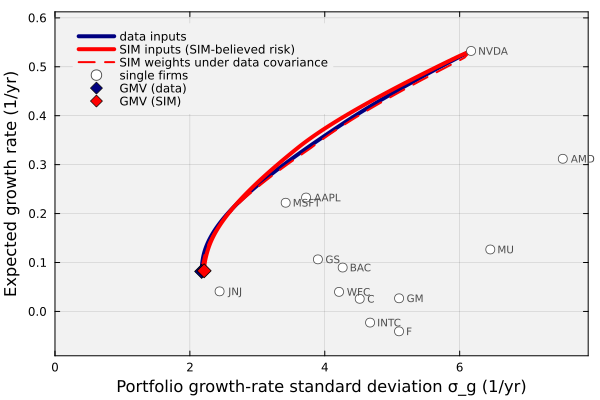

In [15]:
let
    number_of_assets = length(my_list_of_tickers);
    σ_single = sqrt.(diag(Σ̂_g)); # single-firm growth-rate standard deviations
    σ_sim_under_data = [sqrt(w'*Σ̂_g*w) for w ∈ frontier_sim.w]; # SIM weights evaluated under the data covariance

    plot(frontier_data.σ, frontier_data.g, lw = 4, c = :navy, label = "data inputs")
    plot!(frontier_sim.σ, frontier_sim.g, lw = 4, c = :red, label = "SIM inputs (SIM-believed risk)")
    plot!(σ_sim_under_data, frontier_sim.g, lw = 2, ls = :dash, c = :red, label = "SIM weights under data covariance")
    scatter!(σ_single, ĝ, ms = 5, c = :white, msc = :gray30, label = "single firms")
    for i ∈ 1:number_of_assets
        annotate!(σ_single[i] + 0.12, ĝ[i], text(my_list_of_tickers[i], 7, :left, :gray30))
    end
    scatter!([frontier_data.σ[1]], [frontier_data.g[1]], ms = 7, c = :navy, marker = :diamond, label = "GMV (data)")
    scatter!([frontier_sim.σ[1]], [frontier_sim.g[1]], ms = 7, c = :red, marker = :diamond, label = "GMV (SIM)")
    plot!(xlabel = "Portfolio growth-rate standard deviation σ_g (1/yr)", ylabel = "Expected growth rate (1/yr)",
        xlim = (0.0, 1.05*maximum(σ_single)), ylim = (min(0.0, minimum(ĝ)) - 0.05, maximum(ĝ) + 0.08),
        bg = "gray95", background_color_outside = "white", framestyle = :box, fg_legend = :transparent, legend = :topleft)
end

The two frontiers nearly coincide, and the two GMV portfolios are close, because the two input sets share the mean vector and differ only in the residual covariances. To compare them precisely we need a __common__ target: for a set of targets $g_{\star}$ above both GMV growth rates (so that the floor binds for both input sets), we solve the long-only problem from each input set and record three growth-rate standard deviations: what the SIM believes about its own portfolio (`σ_believed`), what the SIM weights carry under the data covariance (`σ_under_data`), and the data-optimal value at that target (`σ_data_opt`). The difference of the last two variances is the __regret__ of using the SIM weights (`regret_var`, units: inverse years squared), which cannot be negative:

In [16]:
let
    number_of_assets = length(my_list_of_tickers);
    bounds = zeros(number_of_assets, 2); bounds[:,2] .= 1.0;
    problem_data = build(MyMarkowitzRiskyAssetOnlyPortfolioChoiceProblem, (Σ = Σ̂_g, μ = ĝ, bounds = bounds, initial = (1/number_of_assets)*ones(number_of_assets), R = 0.0));
    problem_sim = build(MyMarkowitzRiskyAssetOnlyPortfolioChoiceProblem, (Σ = Σ̂_g_sim, μ = ĝ_sim, bounds = bounds, initial = (1/number_of_assets)*ones(number_of_assets), R = 0.0));
    g_low = max(frontier_data.g[1], frontier_sim.g[1]) + 0.01; # above both GMV growth rates, so the floor binds for both
    df = DataFrame(g_target = Float64[], σ_believed = Float64[], σ_under_data = Float64[], σ_data_opt = Float64[], regret_var = Float64[]); # σ_believed: SIM weights under the SIM covariance; σ_under_data: SIM weights under the data covariance; σ_data_opt: data-optimal weights
    for target ∈ range(g_low, stop = maximum(ĝ) - 0.02, length = 6)
        problem_data.R = target; problem_sim.R = target;
        w_data = solve(problem_data)["argmax"]; w_sim = solve(problem_sim)["argmax"];
        push!(df, (g_target = round(target, digits=3), σ_believed = round(sqrt(w_sim'*Σ̂_g_sim*w_sim), digits=3),
            σ_under_data = round(sqrt(w_sim'*Σ̂_g*w_sim), digits=3), σ_data_opt = round(sqrt(w_data'*Σ̂_g*w_data), digits=3),
            regret_var = round(w_sim'*Σ̂_g*w_sim - w_data'*Σ̂_g*w_data, digits=4)));
        @assert w_sim'*Σ̂_g*w_sim ≥ w_data'*Σ̂_g*w_data - 1e-8 # the data-optimal weights minimize the data variance at this target
    end
    pretty_table(df, backend = :text, table_format = TextTableFormat(borders = text_table_borders__compact))
end

 ---------- ------------ -------------- ------------ ------------
  g_target   σ_believed   σ_under_data   σ_data_opt   regret_var 
   Float64      Float64        Float64      Float64      Float64 
 ---------- ------------ -------------- ------------ ------------
     0.093        2.215          2.182        2.179        0.012
     0.177        2.448           2.44        2.424       0.0756
     0.261        2.982          3.066        3.029       0.2216
     0.345        3.696          3.897        3.847       0.3847
     0.429        4.668          4.853        4.788       0.6269
     0.512        5.849          5.986        5.886       1.1902
 ---------- ------------ -------------- ------------ ------------


For the same weights, the SIM-believed variance differs from the data variance by minus the sum of the omitted residual covariances (weighted by the two weights) plus the tiny degrees-of-freedom term on the diagonal, so its sign follows the residual covariances among the firms the optimizer holds. At the low-growth end, where the optimizer spreads wealth across industries, the SIM __overstates__ the risk of its own portfolio: it has thrown away the negative residual correlations between the technology firms and the banks, which is diversification the data contain. At the high-growth end, where the optimizer concentrates in the semiconductor and technology names, the SIM __understates__ the risk: it has thrown away the positive residual correlations inside that group. Under the data covariance the SIM weights sit on or to the right of the data frontier at every common target, as they must. The variance regret in the last column grows from about $0.01$ to $1.2$ (inverse years squared); read as a gap between the two standard deviations (`σ_under_data` minus `σ_data_opt`) it grows from a few thousandths of a unit at the diversified end to a tenth at the concentrated end, on a scale of two to six. The price of the SIM's parsimony for this universe is small, and largest where the portfolio holds the positively-correlated-residual names.
___

## Task 4: What Is in a Data-Driven versus a SIM Portfolio?
Do the two input sets pick different portfolios? Let's compare the weights at the GMV portfolio (`GMV_data`, `GMV_SIM`) and at the target growth rate `g_target` (units: inverse years; columns `tgt_data`, `tgt_SIM`, and their difference `Δ_tgt`), by re-solving the long-only problem at that target for both input sets, and put the beta of each firm next to the weights:

In [17]:
let
    number_of_assets = length(my_list_of_tickers);
    bounds = zeros(number_of_assets, 2); bounds[:,2] .= 1.0;
    w_at_target = Dict{String, Array{Float64,1}}();
    for (name, g_vector, Σ_matrix) ∈ [("data", ĝ, Σ̂_g), ("SIM", ĝ_sim, Σ̂_g_sim)]
        problem = build(MyMarkowitzRiskyAssetOnlyPortfolioChoiceProblem, (Σ = Σ_matrix, μ = g_vector, bounds = bounds, initial = (1/number_of_assets)*ones(number_of_assets), R = g_target));
        solution = solve(problem);
        @assert solution["status"] == MathOptInterface.LOCALLY_SOLVED
        w_at_target[name] = solution["argmax"];
    end
    df = DataFrame(ticker = my_list_of_tickers, β̂ = round.(β̂, digits=2),
        GMV_data = round.(frontier_data.w[1], digits=4) .+ 0.0, GMV_SIM = round.(frontier_sim.w[1], digits=4) .+ 0.0,
        tgt_data = round.(w_at_target["data"], digits=4) .+ 0.0, tgt_SIM = round.(w_at_target["SIM"], digits=4) .+ 0.0);
    df.Δ_tgt = round.(w_at_target["data"] .- w_at_target["SIM"], digits=4) .+ 0.0; # data minus SIM weight at the target
    pretty_table(df, backend = :text, table_format = TextTableFormat(borders = text_table_borders__compact))
    for name ∈ ["data", "SIM"]
        w = w_at_target[name];
        println("target $(g_target) 1/yr, $(name) weights: E[g] = $(round(ĝ'*w, digits=4)) 1/yr, σ_g under the data covariance = $(round(sqrt(w'*Σ̂_g*w), digits=4)) 1/yr")
    end
end

 -------- --------- ---------- --------- ---------- --------- ---------
  ticker         β̂   GMV_data   GMV_SIM   tgt_data   tgt_SIM     Δ_tgt 
  String   Float64    Float64   Float64    Float64   Float64   Float64 
 -------- --------- ---------- --------- ---------- --------- ---------
    AAPL      1.19     0.0902    0.0879     0.1641    0.2063   -0.0422
    MSFT      1.15     0.1423    0.1417     0.2024    0.2764   -0.0741
    INTC      1.18      0.041    0.0441        0.0       0.0       0.0
      MU       1.7        0.0       0.0        0.0       0.0       0.0
     AMD      1.74        0.0       0.0        0.0    0.0031   -0.0031
    NVDA      1.75        0.0       0.0     0.1849    0.1394    0.0455
      GS      1.31     0.0236    0.0316        0.0       0.0       0.0
     BAC      1.36        0.0    0.0057        0.0       0.0       0.0
     WFC      1.24     0.0595    0.0455        0.0       0.0       0.0
       C       1.5        0.0       0.0        0.0       0.0       0.0
 

The two allocations select nearly the same firms (they differ only in names held at a few tenths of a percent) and differ by up to seven percentage points in the weights. The differences are not a function of beta alone (the SIM tilts toward the two large technology firms and away from the best-performing semiconductor firm and the health-care name at this target), and the growth-rate standard deviation the SIM weights carry under the data covariance is only slightly above the data-optimal value. For a universe like this one, where most residual correlations are small even though a few industry pairs are large, the SIM buys a great deal of parsimony for very little in-sample cost; the cost grows with the residual correlations among the firms the optimizer chooses to hold.
___

## Task 5: How Did the Portfolios Do Out of Sample?
Everything above was estimated from 2014 to 2024. As in L5b, let's see how the two GMV portfolios, the two target-growth portfolios, an equal-weight portfolio, and the [SPY ETF](https://en.wikipedia.org/wiki/SPDR_S%26P_500) would have done as __buy-and-hold__ portfolios in calendar year 2025. Buy-and-hold wealth for initial weights $\mathbf{w}$ and initial wealth $W_{0}$ is $W_{t}=W_{0}\sum_{i}w_{i}\,S_{i}(t)/S_{i}(0)$ (L5a); we use the volume-weighted average price for $S_{i}(t)$ (a price-only comparison: dividends are not included, for the firms or for SPY), the same first trading day and the same $W_{0}$ for every portfolio, and weights fixed from the training data. First, we build the 2025 price matrix (rows are trading days, columns are firms) and store it in the `prices_2025::Array{Float64,2}` variable:

In [18]:
prices_2025 = let
    N = nrow(dataset_2025["AAPL"]); number_of_assets = length(my_list_of_tickers);
    S = Array{Float64,2}(undef, N, number_of_assets);
    for (i, ticker) ∈ enumerate(my_list_of_tickers)
        S[:,i] = dataset_2025[ticker][:, :volume_weighted_average_price];
    end
    S; # return
end;

Next, we compute the wealth paths and collect them in the `wealth_2025::Dict{String,Array{Float64,1}}` variable, keyed by portfolio name (the two target-growth portfolios are re-solved at `g_target`, as in the previous task):

In [19]:
wealth_2025 = let
    number_of_assets = length(my_list_of_tickers);
    bounds = zeros(number_of_assets, 2); bounds[:,2] .= 1.0;
    portfolios = Dict{String, Array{Float64,1}}("GMV (data)" => frontier_data.w[1], "GMV (SIM)" => frontier_sim.w[1], "equal weights" => (1/number_of_assets)*ones(number_of_assets));
    for (name, g_vector, Σ_matrix) ∈ [("target (data)", ĝ, Σ̂_g), ("target (SIM)", ĝ_sim, Σ̂_g_sim)]
        problem = build(MyMarkowitzRiskyAssetOnlyPortfolioChoiceProblem, (Σ = Σ_matrix, μ = g_vector, bounds = bounds, initial = (1/number_of_assets)*ones(number_of_assets), R = g_target));
        portfolios[name] = solve(problem)["argmax"];
    end

    price_ratio = prices_2025 ./ prices_2025[1,:]'; # S_i(t)/S_i(0), one column per firm
    wealth = Dict{String, Array{Float64,1}}();
    for (name, w) ∈ portfolios
        wealth[name] = W₀*(price_ratio*w); # buy-and-hold wealth path
    end
    spy = dataset_2025["SPY"][:, :volume_weighted_average_price];
    wealth["SPY"] = W₀*(spy ./ spy[1]);
    wealth; # return
end;

Let's plot the scaled wealth paths, $W_{t}/W_{0}$, over the 2025 trading days. `Unhide` the code block below to see how:

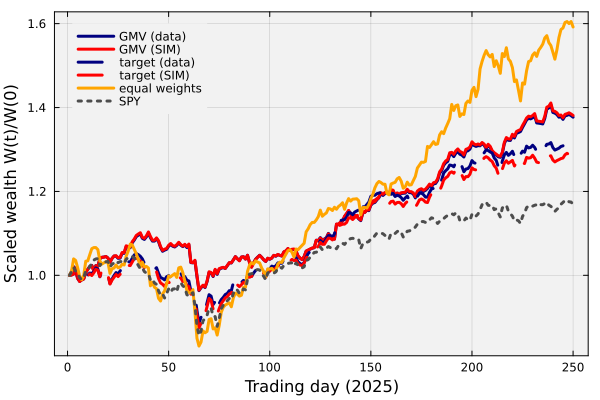

In [20]:
let
    p = plot();
    for (name, c, ls) ∈ [("GMV (data)", :navy, :solid), ("GMV (SIM)", :red, :solid), ("target (data)", :navy, :dash), ("target (SIM)", :red, :dash), ("equal weights", :orange, :solid), ("SPY", :gray30, :dot)]
        plot!(wealth_2025[name] ./ W₀, lw = 3, c = c, ls = ls, label = name)
    end
    plot!(xlabel = "Trading day (2025)", ylabel = "Scaled wealth W(t)/W(0)",
        bg = "gray95", background_color_outside = "white", framestyle = :box, fg_legend = :transparent, legend = :topleft)
end

Finally, a scorecard: the year-end wealth ratio, the realized 2025 growth rate $\ln(W_{T}/W_{0})/T$ with $T$ in years, and the realized growth-rate standard deviation of each wealth path (the daily log growth of wealth, in the same units as the training estimates), [using the `diff(...)` function](https://docs.julialang.org/en/v1/base/arrays/#Base.diff) for the daily log changes:

In [21]:
let
    df = DataFrame(portfolio = String[], W_T_over_W_0 = Float64[], growth_2025 = Float64[], σ_g_2025 = Float64[]);
    for name ∈ ["GMV (data)", "GMV (SIM)", "target (data)", "target (SIM)", "equal weights", "SPY"]
        W = wealth_2025[name]; T = (length(W) - 1)*Δt; # holding period in years
        g_daily = diff(log.(W)) ./ Δt; # realized daily growth rates of wealth (units: 1/years)
        push!(df, (portfolio = name, W_T_over_W_0 = round(W[end]/W[1], digits=4), growth_2025 = round(log(W[end]/W[1])/T, digits=4), σ_g_2025 = round(std(g_daily), digits=3)));
    end
    pretty_table(df, backend = :text, table_format = TextTableFormat(borders = text_table_borders__compact))
end

 --------------- -------------- ------------- ----------
      portfolio   W_T_over_W_0   growth_2025   σ_g_2025 
         String        Float64       Float64    Float64 
 --------------- -------------- ------------- ----------
     GMV (data)          1.377        0.3238      1.996
      GMV (SIM)         1.3812        0.3268      2.019
  target (data)         1.3134        0.2759      2.039
   target (SIM)         1.2831        0.2523      2.059
  equal weights         1.5921        0.4706      3.487
            SPY         1.1691        0.1581      2.206
 --------------- -------------- ------------- ----------


The paired portfolios track each other closely: the two GMV portfolios are nearly indistinguishable, and the two target-growth portfolios end the year a few percent of wealth apart, which is what the weight table predicted (at that target the SIM tilted toward the two large technology firms and away from the best-performing semiconductor firm and the health-care name). That is the honest reading of this check. It says the SIM inputs cost little for this universe; it does not say which input set is better, because one year, one draw, and a universe fixed before the year began cannot separate two portfolios that differ by a few percentage points, and both minimum-variance portfolios were built from covariance estimates whose errors L5b's advanced material showed to be much larger than the SIM-versus-data gap. The second example adds the risk-free asset and asks the same question of the tangent portfolio.
___

## Summary
In this example, we assembled the minimum-variance inputs for thirteen firms from the training data and from the single index model archive, showed that the SIM mean vector reproduces the sample means and that the SIM covariance is the sample covariance with the residual covariances removed, traced the long-only efficient frontier from each input set, compared the weights, and scored the portfolios on 2025 data.

> __Key Takeaways:__
>
> * **The SIM changes only the covariance:** A least-squares fit with an intercept passes through the sample means, so the SIM mean vector equals the sample-mean vector when both come from the same training days, and the SIM covariance differs from the sample covariance exactly by the off-diagonal residual covariances (and a negligible degrees-of-freedom factor on the diagonal).
> * **The covariance error has a sign structure:** In this universe the residuals are positively correlated inside an industry (strongly, for the banks) and negatively correlated between the technology firms and the banks, so the SIM overstates the risk of diversified low-growth portfolios and understates the risk of concentrated high-growth ones; evaluated under the data covariance, the SIM weights sit only slightly to the right of the data frontier.
> * **Out of sample the two are nearly indistinguishable:** The paired GMV and target-growth portfolios selected almost the same weights and earned almost the same 2025 wealth, which shows the SIM's parsimony is cheap for this universe, and which one year of data cannot turn into a ranking.

The second example adds a risk-free asset to the SIM inputs, finds the tangent portfolio and the capital allocation line, and scores complete portfolios that lend or borrow against it.
___

## Disclaimer and Risks
__This content is offered solely for training and informational purposes__. No offer or solicitation to buy or sell securities or derivative products or any investment or trading advice or strategy is made, given, or endorsed by the teaching team. 

__Trading involves risk__. Carefully review your financial situation before investing in securities, futures contracts, options, or commodity interests. Past performance, whether actual or indicated by historical tests of strategies, is no guarantee of future performance or success. Trading is generally inappropriate for someone with limited resources, investment or trading experience, or a low-risk tolerance. Only risk capital that is not required for living expenses should be used.

__You are fully responsible for any investment or trading decisions you make__. Such decisions should be based solely on evaluating your financial circumstances, investment or trading objectives, risk tolerance, and liquidity needs.

___